In [ ]:
!pip install -q segmentation-models-pytorch albumentations torchmetrics pytorch-lightning clearml python-dotenv gdown

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 77.0 MB/s eta 0:00:00


In [ ]:
import os
import math
import shutil
from pathlib import Path

import torch
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
import albumentations as A
import segmentation_models_pytorch as smp
import pytorch_lightning as pl
from pytorch_lightning.callbacks import Callback, TQDMProgressBar
from torch.utils.data import DataLoader, Dataset
from torchmetrics import JaccardIndex
from albumentations.pytorch import ToTensorV2
from clearml import Task
import cv2
import numpy as np
from google.colab import files
from dotenv import load_dotenv
import gdown
import zipfile
from concurrent.futures import ProcessPoolExecutor

In [ ]:
from google.colab import userdata, drive

os.environ['CLEARML_API_ACCESS_KEY'] = userdata.get('CLEARML_API_ACCESS_KEY')
os.environ['CLEARML_API_SECRET_KEY'] = userdata.get('CLEARML_API_SECRET_KEY')

In [ ]:
drive.mount('/content/drive')


source_path = '/content/drive/MyDrive/'

tasks = [
    {
        "files": ["leftImg8bit_trainvaltest.zip", "gtFine_trainvaltest.zip"],
        "dest": "/content/data/cityscapes/"
    }
]

for task in tasks:
    if not os.path.exists(task["dest"]):
        os.makedirs(task["dest"])

    for zip_file in task["files"]:
        full_path = os.path.join(source_path, zip_file)

        if os.path.exists(full_path):
            print(f"Unpacking {zip_file} in {task['dest']}...")
            !unzip -q -o "{full_path}" -d "{task['dest']}"
        else:
            print(f"Error, file not found: {full_path}")

Mounted at /content/drive
Unpacking leftImg8bit_trainvaltest.zip in /content/data/cityscapes/...
Unpacking gtFine_trainvaltest.zip in /content/data/cityscapes/...


In [ ]:
CONFIG = {
    "project_name": "Segmentation_Urban_Scene_CourseWork",
    "task_name": "SegFormer_B2_Cityscapes_E2_ClassBalancedFocal",
    "data_dir": "./data/cityscapes",
    "encoder": "mit_b2",
    "encoder_weights": "imagenet",
    "classes": 19,
    "batch_size": 8,
    "lr": 1e-4,
    "momentum": 0.9,
    "weight_decay": 0.01,
    "epochs": 50,
    "image_size": (512, 1024),
    "loss_name": "weighted_focal",
    "focal_gamma": 2.0,
    "focal_ce_balance": 0.5,
    "class_weights": None,  # auto-computed from Cityscapes train split
    "device": "cuda" if torch.cuda.is_available() else "cpu"
}

# Set precision for Tensor Cores
torch.set_float32_matmul_precision('medium')

# Set allocator to avoid fragmentation
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

task = Task.init(
    project_name=CONFIG["project_name"],
    task_name=CONFIG["task_name"],
    output_uri=False
)
task.connect(CONFIG)

def compute_cityscapes_class_weights(data_dir, num_classes=19, c=1.02):
    """Compute ENet-style class weights from Cityscapes train split masks."""
    mapping = {
        7: 0, 8: 1, 11: 2, 12: 3, 13: 4, 17: 5, 19: 6, 20: 7, 21: 8, 22: 9,
        23: 10, 24: 11, 25: 12, 26: 13, 27: 14, 28: 15, 31: 16, 32: 17, 33: 18
    }

    masks_root = Path(data_dir) / 'gtFine' / 'train'
    if not masks_root.exists():
        raise FileNotFoundError(f'Missing Cityscapes train masks: {masks_root}')

    counts = np.zeros(num_classes, dtype=np.float64)

    for city_dir in sorted(masks_root.iterdir()):
        if not city_dir.is_dir():
            continue
        for mask_path in city_dir.glob('*_gtFine_labelIds.png'):
            mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
            if mask is None:
                continue
            for src_id, train_id in mapping.items():
                counts[train_id] += np.sum(mask == src_id)

    total = counts.sum()
    if total <= 0:
        raise RuntimeError('No valid labeled pixels found for class-weight computation.')

    probs = counts / total
    weights = 1.0 / np.log(c + probs)
    weights = (weights / weights.mean()).tolist()
    return [float(f'{w:.6f}') for w in weights]


ClearML Task: created new task id=5e3eff31de174f3192235a5b2eb28f9a


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


ClearML results page: https://app.clear.ml/projects/588d5d925230490b9f98b1007b4c7fa0/experiments/5e3eff31de174f3192235a5b2eb28f9a/output/log


In [ ]:
class CityscapesDataset(Dataset):
    def __init__(self, root_dir, split='train', augmentation=None, preprocessing=None):
        self.root_dir = root_dir
        self.images_dir = os.path.join(root_dir, 'leftImg8bit', split)
        self.masks_dir = os.path.join(root_dir, 'gtFine', split)
        self.augmentation = augmentation
        self.preprocessing = preprocessing
        self.ids = []

        for city in os.listdir(self.images_dir):
            img_dir = os.path.join(self.images_dir, city)
            mask_dir = os.path.join(self.masks_dir, city)
            for file_name in os.listdir(img_dir):
                if file_name.endswith('_leftImg8bit.png'):
                   self.ids.append({
                       'image': os.path.join(img_dir, file_name),
                       'mask': os.path.join(mask_dir, file_name.replace('_leftImg8bit.png', '_gtFine_labelIds.png'))
                   })

        self.mapping = {
            7: 0, 8: 1, 11: 2, 12: 3, 13: 4, 17: 5, 19: 6, 20: 7, 21: 8, 22: 9,
            23: 10, 24: 11, 25: 12, 26: 13, 27: 14, 28: 15, 31: 16, 32: 17, 33: 18
        }

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, i):
        sample = self.ids[i]
        image = cv2.imread(sample['image'])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(sample['mask'], 0)

        mask_mapped = np.ones_like(mask) * 255
        for k, v in self.mapping.items():
            mask_mapped[mask == k] = v
        mask = mask_mapped

        if self.augmentation:
            sample = self.augmentation(image=image, mask=mask)
            image, mask = sample['image'], sample['mask']

        if self.preprocessing:
            sample = self.preprocessing(image=image, mask=mask)
            image, mask = sample['image'], sample['mask']

        return image, mask.long()

In [ ]:
def _to_float32(image, **kwargs):
    return image.astype(np.float32)


class RoadDataModule(pl.LightningDataModule):
    def __init__(self, data_dir, batch_size, image_size, encoder, encoder_weights):
        super().__init__()
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.image_size = image_size
        self.preprocessing_fn = smp.encoders.get_preprocessing_fn(encoder, encoder_weights)

    def setup(self, stage=None):
        self.train_transform = A.Compose([
            A.Resize(height=self.image_size[0], width=self.image_size[1]),
            A.HorizontalFlip(p=0.5),
            A.ShiftScaleRotate(scale_limit=0.1, rotate_limit=10, p=0.5),
            A.OneOf([
                A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=1.0),
                A.RandomGamma(gamma_limit=(70, 120), p=1.0),
                A.RandomBrightnessContrast(brightness_limit=0.35, contrast_limit=0.35, p=1.0),
                A.RandomShadow(p=1.0),
            ], p=0.75),
            A.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.2, hue=0.08, p=0.4),
            A.OneOf([
                A.RandomFog(p=1.0),
                A.RandomRain(blur_value=3, brightness_coefficient=0.9, p=1.0),
                A.RandomSnow(p=1.0),
            ], p=0.35),
            A.OneOf([
                A.GaussNoise(p=1.0),
                A.GaussianBlur(blur_limit=(3, 7), p=1.0),
                A.MotionBlur(blur_limit=5, p=1.0),
            ], p=0.25),
        ])

        self.valid_transform = A.Compose([
            A.Resize(height=self.image_size[0], width=self.image_size[1]),
        ])

        self.preprocessing = A.Compose([
            A.Lambda(image=self.preprocessing_fn),
            A.Lambda(image=_to_float32),
            A.pytorch.ToTensorV2()
        ])

        self.train_ds = CityscapesDataset(self.data_dir, split='train', augmentation=self.train_transform, preprocessing=self.preprocessing)
        self.val_ds = CityscapesDataset(self.data_dir, split='val', augmentation=self.valid_transform, preprocessing=self.preprocessing)

    def train_dataloader(self):
        return DataLoader(self.train_ds, batch_size=self.batch_size, shuffle=True, num_workers=2, pin_memory=True)

    def val_dataloader(self):
        return DataLoader(self.val_ds, batch_size=self.batch_size, shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
from torch.optim.lr_scheduler import SequentialLR, LinearLR, PolynomialLR

class ClearMLMetricsCallback(Callback):
    def __init__(self, task):
        super().__init__()
        self._logger = task.get_logger()

    def _log_metrics(self, trainer, stage):
        for name, value in trainer.callback_metrics.items():
            if isinstance(value, torch.Tensor):
                value = value.detach().cpu().item()
            if isinstance(value, (int, float)) and math.isfinite(value):
                self._logger.report_scalar(stage, name, value, iteration=trainer.current_epoch)

    def on_train_epoch_end(self, trainer, pl_module):
        self._log_metrics(trainer, "train")

    def on_validation_epoch_end(self, trainer, pl_module):
        self._log_metrics(trainer, "val")


class RoadModel(pl.LightningModule):
    def __init__(self, encoder, encoder_weights, in_channels, out_classes, lr=1e-4, weight_decay=0.01, epochs=50,
                 loss_name='weighted_focal', focal_gamma=2.0, focal_ce_balance=0.5, class_weights=None):
        super().__init__()
        self.save_hyperparameters()

        self.model = smp.Segformer(
            encoder_name=encoder,
            encoder_weights=encoder_weights,
            in_channels=in_channels,
            classes=out_classes,
        )

        self.loss_name = loss_name
        self.focal_gamma = focal_gamma
        self.focal_ce_balance = focal_ce_balance
        if class_weights is not None:
            cw = torch.tensor(class_weights, dtype=torch.float32)
            self.register_buffer('class_weights', cw)
        else:
            self.class_weights = None

        self.train_miou = JaccardIndex(task="multiclass", num_classes=out_classes, ignore_index=255)
        self.val_miou = JaccardIndex(task="multiclass", num_classes=out_classes, ignore_index=255)

    def forward(self, x):
        return self.model(x)

    def compute_loss(self, logits, masks):
        ce_loss = F.cross_entropy(
            logits,
            masks,
            ignore_index=255,
            weight=self.class_weights if hasattr(self, 'class_weights') else None
        )

        if self.loss_name in ('focal', 'weighted_focal'):
            probs = torch.softmax(logits, dim=1)
            targets = masks.clone()
            valid = targets != 255
            if valid.sum() == 0:
                return ce_loss

            # Prevent ignore_index (255) from being used as gather indices.
            targets_safe = targets.clone()
            targets_safe[~valid] = 0
            targets_safe = targets_safe.clamp(min=0, max=logits.shape[1] - 1)

            pt = probs.gather(1, targets_safe.unsqueeze(1)).squeeze(1)
            pt_valid = pt[valid].clamp(1e-6, 1 - 1e-6)
            focal_loss = (-(1.0 - pt_valid) ** self.focal_gamma * torch.log(pt_valid)).mean()
            return self.focal_ce_balance * ce_loss + (1.0 - self.focal_ce_balance) * focal_loss

        return ce_loss

    def training_step(self, batch, batch_idx):
        images, masks = batch
        logits = self(images)

        loss = self.compute_loss(logits, masks)

        preds = torch.argmax(logits, dim=1)
        self.train_miou(preds, masks)

        self.log("train_loss", loss, on_step=True, on_epoch=True, prog_bar=True, logger=True)
        self.log("train_miou", self.train_miou, on_step=False, on_epoch=True, prog_bar=True, logger=True)
        return loss

    def validation_step(self, batch, batch_idx):
        images, masks = batch
        logits = self(images)
        loss = self.compute_loss(logits, masks)

        preds = torch.argmax(logits, dim=1)
        self.val_miou(preds, masks)

        self.log("val_loss", loss, on_epoch=True, prog_bar=True, logger=True)
        self.log("val_miou", self.val_miou, on_epoch=True, prog_bar=True, logger=True)

        if batch_idx == 0:
            experiment = getattr(self.logger, "experiment", None)
            if experiment is not None and hasattr(experiment, "report_image"):
                experiment.report_image(
                    "Validation Prediction",
                    "Image_0",
                    iteration=self.current_epoch,
                    image=preds[0].float().cpu().numpy() / 19.0 * 255
                )

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.parameters(),
            lr=self.hparams.lr,
            weight_decay=self.hparams.weight_decay,
            betas=(0.9, 0.999),
            eps=1e-8
        )

        total_steps = self.trainer.estimated_stepping_batches
        warmup_steps = 1500

        decay_steps = total_steps - warmup_steps
        if decay_steps < 0:
            decay_steps = 1

        scheduler1 = LinearLR(
            optimizer,
            start_factor=0.01,
            end_factor=1.0,
            total_iters=warmup_steps
        )

        scheduler2 = PolynomialLR(
            optimizer,
            total_iters=decay_steps,
            power=0.9
        )

        scheduler = SequentialLR(
            optimizer,
            schedulers=[scheduler1, scheduler2],
            milestones=[warmup_steps]
        )

        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "interval": "step",
                "frequency": 1
            }
        }

In [10]:

if CONFIG["class_weights"] is None:
    CONFIG["class_weights"] = compute_cityscapes_class_weights(
        CONFIG["data_dir"],
        num_classes=CONFIG["classes"]
    )
    print("Computed class weights from Cityscapes train split:")
    print(CONFIG["class_weights"])
    task.connect({"computed_class_weights": CONFIG["class_weights"]})

dm = RoadDataModule(
    CONFIG["data_dir"],
    CONFIG["batch_size"],
    CONFIG["image_size"],
    CONFIG["encoder"],
    CONFIG["encoder_weights"]
)

model = RoadModel(
    encoder=CONFIG["encoder"],
    encoder_weights=CONFIG["encoder_weights"],
    in_channels=3,
    out_classes=CONFIG["classes"],
    lr=CONFIG["lr"],
    weight_decay=CONFIG["weight_decay"],
    epochs=CONFIG["epochs"],
    loss_name=CONFIG["loss_name"],
    focal_gamma=CONFIG["focal_gamma"],
    focal_ce_balance=CONFIG["focal_ce_balance"],
    class_weights=CONFIG["class_weights"]
)

checkpoint_callback = pl.callbacks.ModelCheckpoint(
    monitor="val_miou",
    dirpath="./checkpoints",
    filename="segformer-b2-E2-cityscapes-{epoch:02d}-{val_miou:.2f}",
    save_top_k=1,
    mode="max",
)

trainer = pl.Trainer(
    max_epochs=CONFIG["epochs"],
    accelerator="gpu",
    devices=1,
    logger=True,
    callbacks=[
        checkpoint_callback,
        TQDMProgressBar(refresh_rate=20),
        ClearMLMetricsCallback(task)
    ],
    precision="16-mixed",
    accumulate_grad_batches=4
)

trainer.fit(model, datamodule=dm)

Computed class weights from Cityscapes train split:
[0.099448, 0.420017, 0.147272, 1.246027, 1.151191, 1.028075, 1.49536, 1.296222, 0.19802, 1.050353, 0.558707, 1.03071, 1.545706, 0.37915, 1.456441, 1.47723, 1.478727, 1.572281, 1.369062]


config.json:   0%|          | 0.00/135 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/98.9M [00:00<?, ?B/s]

INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning:

ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loading `train_dataloader` to estimate number of stepping batches.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: FutureWarni

┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type                   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model      │ Segformer              │ 24.7 M │ train │     0 │
│ 1 │ train_miou │ MulticlassJaccardIndex │      0 │ train │     0 │
│ 2 │ val_miou   │ MulticlassJaccardIndex │      0 │ train │     0 │
└───┴────────────┴────────────────────────┴────────┴───────┴───────┘

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         val_loss          │     0.198117196559906     │
│         val_miou          │    0.7125303149223328     │
└───────────────────────────┴───────────────────────────┘


Results:



,Metric,Value
0,Loss,0.1981
1,mIoU,0.7125
2,Percent,71.25%


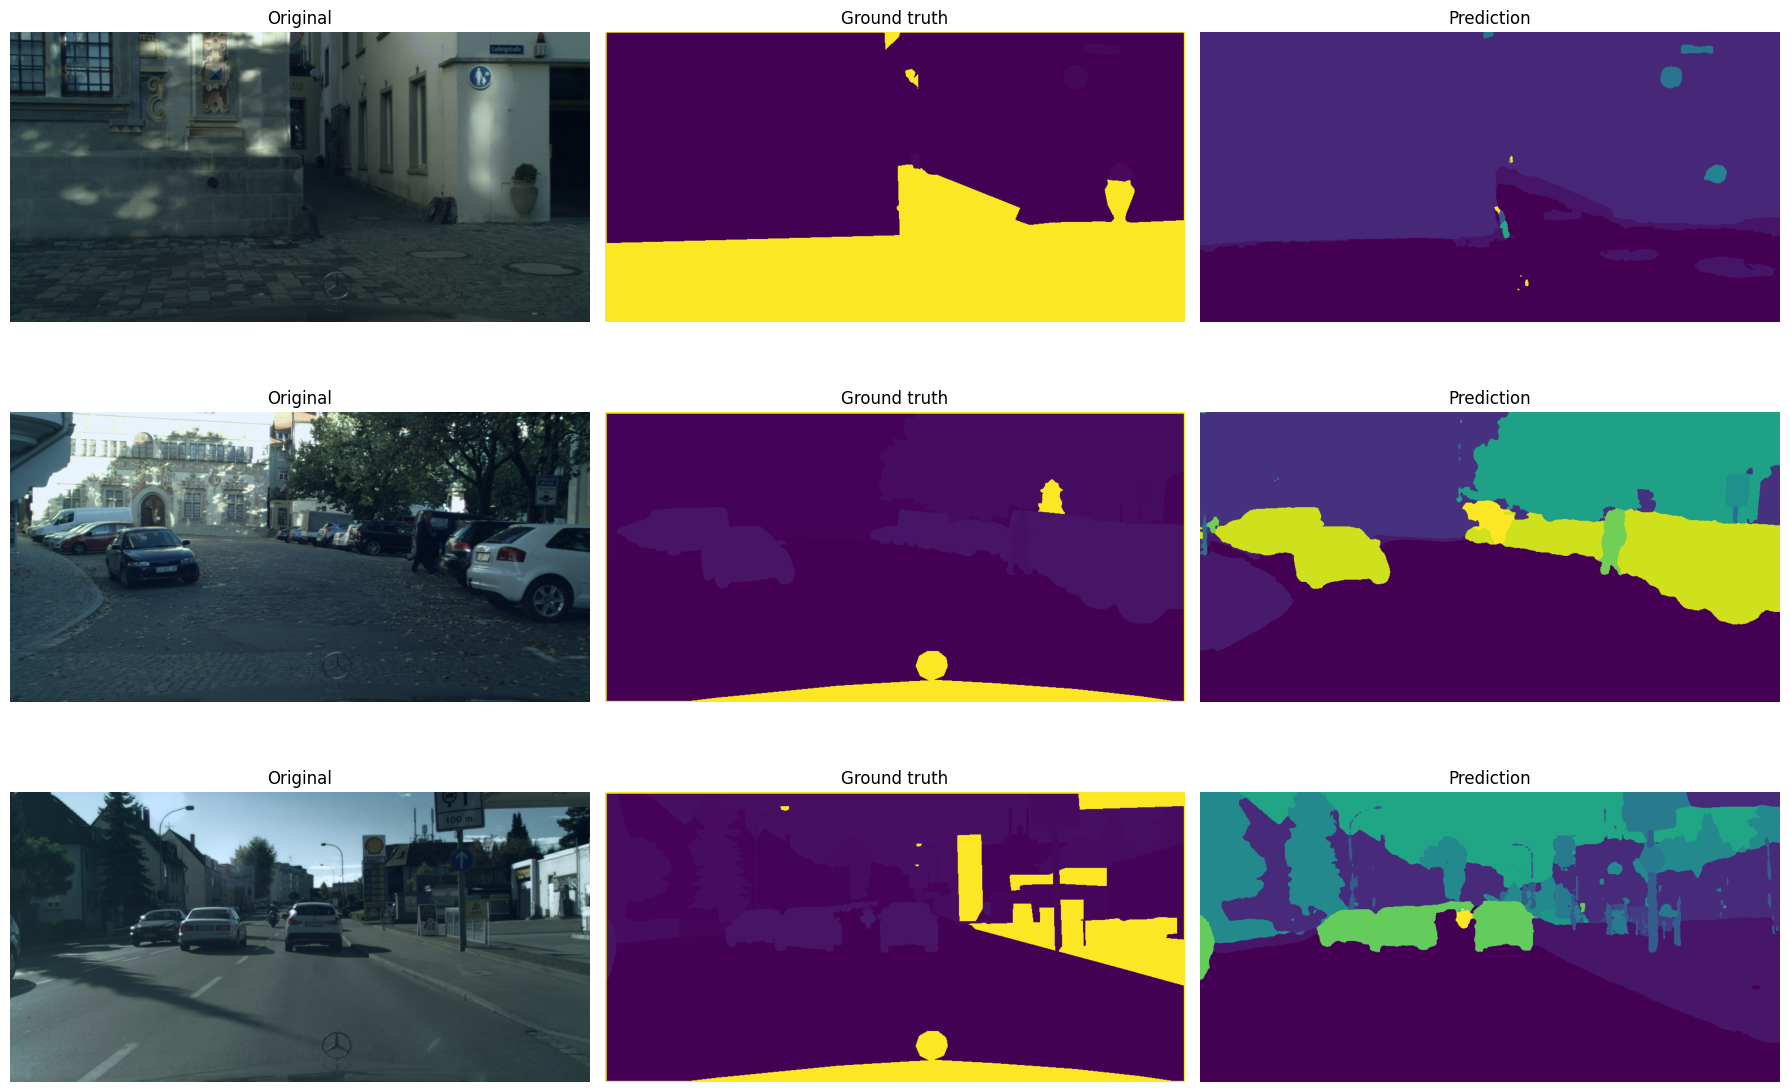

In [11]:
best_model_path = trainer.checkpoint_callback.best_model_path

best_model = RoadModel.load_from_checkpoint(best_model_path)
best_model.to(CONFIG["device"])
best_model.eval()


val_results = trainer.validate(best_model, datamodule=dm)[0]

metrics_data = {
    "Metric": ["Loss", "mIoU", "Percent"],
    "Value": [
        f"{val_results['val_loss']:.4f}",
        f"{val_results['val_miou']:.4f}",
        f"{val_results['val_miou']*100:.2f}%"
    ]
}
df = pd.DataFrame(metrics_data)

print("\n" + "="*30)
print("Results:" + "\n")
print("="*30)
display(df)

def visualize_predictions(model, datamodule, num_samples=3):
    model.to(CONFIG["device"])
    model.eval()

    val_loader = datamodule.val_dataloader()
    images, masks = next(iter(val_loader))

    images = images.to(CONFIG["device"])
    with torch.no_grad():
        logits = model(images)
        preds = torch.argmax(logits, dim=1)

    images = images.cpu()
    masks = masks.cpu()
    preds = preds.cpu()

    plt.figure(figsize=(18, num_samples * 4))

    for i in range(num_samples):
        img = images[i].permute(1, 2, 0).numpy()
        img = (img - img.min()) / (img.max() - img.min())

        plt.subplot(num_samples, 3, i*3 + 1)
        plt.imshow(img)
        plt.title("Original")
        plt.axis("off")

        plt.subplot(num_samples, 3, i*3 + 2)
        plt.imshow(masks[i])
        plt.title("Ground truth")
        plt.axis("off")

        plt.subplot(num_samples, 3, i*3 + 3)
        plt.imshow(preds[i])
        plt.title(f"Prediction")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

visualize_predictions(best_model, dm)

In [ ]:
best_model_path = trainer.checkpoint_callback.best_model_path

model_name = os.path.basename(best_model_path)

current_task = Task.get_task(task_id=task.id)

current_task.update_output_model(
    model_path=best_model_path,
    model_name=model_name,
    iteration=trainer.current_epoch
)

In [13]:
task.close()

█████████████████████████████ 100% | 283.39/283.39 MB [00:08<00:00, 31.99MB/s]: 


In [14]:
from google.colab import runtime
runtime.unassign()